# Hiểu Wavelet

## So sánh

In [10]:
def display_images(*images, titles=None, max_cols=5):
    num_images = min(len(images), 12)  # Giới hạn tối đa 10 ảnh
    
    if num_images == 0:
        print("No images to display.")
        return
    
    # Tính toán số hàng và cột
    cols = min(num_images, max_cols)
    rows = (num_images + cols - 1) // cols
    
    # Tạo figure
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    
    # Ép kiểu axes thành mảng 1 chiều để dễ truy vấn trong vòng lặp
    if num_images == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
        
    for i in range(num_images):
        img = images[i]
        
        # Kiểm tra nếu là ảnh xám (2D) hoặc ảnh màu (3D)
        if len(img.shape) == 2:
            axes[i].imshow(img, cmap='gray')
        else:
            axes[i].imshow(img)
            
        # Thiết lập tiêu đề
        title = titles[i] if titles and i < len(titles) else f"Image {i+1}"
        axes[i].set_title(title)
        axes[i].axis('off')
    
    # Ẩn các ô subplot dư thừa nếu có
    for i in range(num_images, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

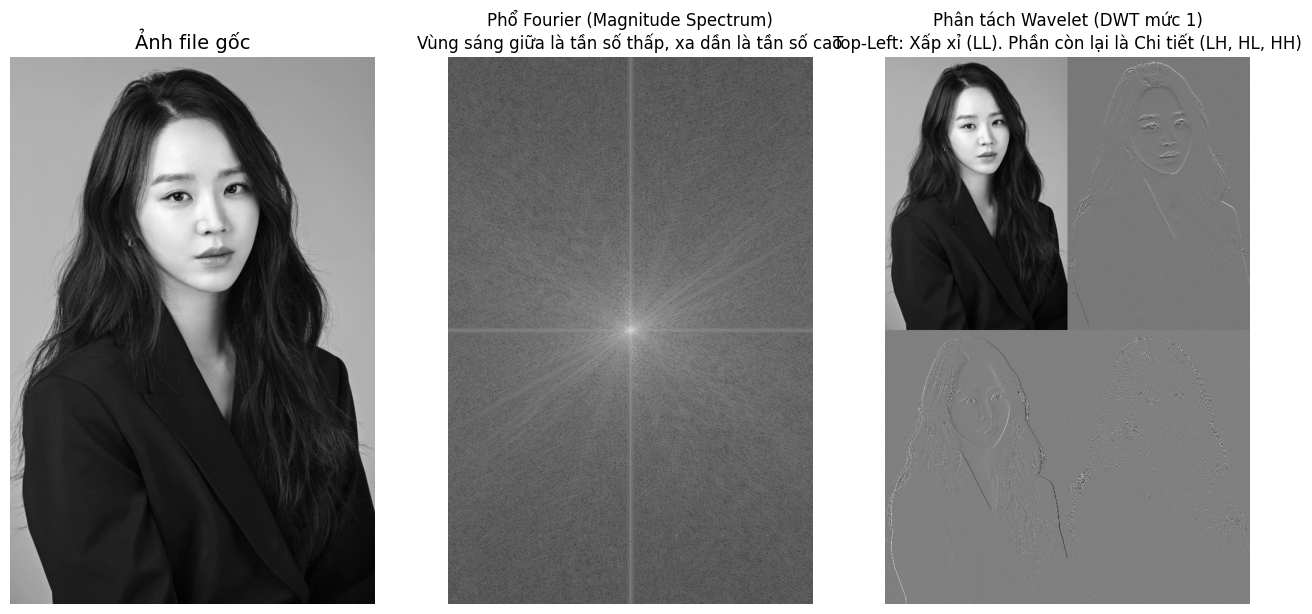

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt
import pywt.data

def compare_transforms_on_image(image_path=None):
    # 1. Load ảnh input
    if image_path:
        # Load ảnh từ file (chuyển sang ảnh xám)
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Không thể load ảnh từ: {image_path}")
            return
        title_prefix = "Ảnh file"
    else:
        # Nếu không có file, dùng ảnh mẫu 'camera' của PyWavelets
        img = pywt.data.camera()
        title_prefix = "Ảnh mẫu"

    # Chuyển sang kiểu float để tính toán chính xác
    img_float = np.float32(img)

    # ==========================================
    # 2. Phép Biến đổi Fourier (DFT)
    # ==========================================
    # Tính DFT 2 chiều
    dft = cv2.dft(img_float, flags=cv2.DFT_COMPLEX_OUTPUT)
    # Dịch chuyển thành phần tần số thấp vào trung tâm
    dft_shift = np.fft.fftshift(dft)
    
    # Tính phổ biên độ (Magnitude Spectrum) để visualize
    # Công thức: log(1 + sqrt(Re^2 + Im^2)) - dùng log để nén dải giá trị
    magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1)

    # ==========================================
    # 3. Phép Biến đổi Wavelet (DWT - 2D)
    # ==========================================
    # Sử dụng Wavelet 'haar' và phân tách mức 1
    coeffs = pywt.dwt2(img_float, 'haar')
    LL, (LH, HL, HH) = coeffs

    # Visualize các thành phần Wavelet
    # LL: Ảnh xấp xỉ (Approximation) - chứa thông tin chính, tần số thấp
    # LH: Chi tiết ngang (Horizontal detail) - chứa các cạnh ngang
    # HL: Chi tiết dọc (Vertical detail) - chứa các cạnh dọc
    # HH: Chi tiết chéo (Diagonal detail) - chứa các chi tiết chéo, nhiễu

    # Ghép các thành phần lại thành một ảnh lớn để dễ nhìn
    # Quy chuẩn giá trị về 0-255 để hiển thị
    def normalize_image(image):
        if image.max() == image.min(): return np.zeros_like(image, dtype=np.uint8)
        return cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    LL_norm = normalize_image(LL)
    LH_norm = normalize_image(LH)
    HL_norm = normalize_image(HL)
    HH_norm = normalize_image(HH)

    # Tạo ảnh ghép Wavelet
    top_row = np.hstack((LL_norm, LH_norm))
    bottom_row = np.hstack((HL_norm, HH_norm))
    wavelet_composite = np.vstack((top_row, bottom_row))


    plt.figure(figsize=(16, 10))

    # --- Hiển thị Ảnh gốc ---
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{title_prefix} gốc", fontsize=14)
    plt.axis('off')

    # --- Hiển thị Phổ Fourier ---
    plt.subplot(1, 3, 2)
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title("Phổ Fourier (Magnitude Spectrum)\nVùng sáng giữa là tần số thấp, xa dần là tần số cao", fontsize=12)
    plt.axis('off')

    # --- Hiển thị Phân tách Wavelet ---
    plt.subplot(1, 3, 3)
    plt.imshow(wavelet_composite, cmap='gray')
    plt.title("Phân tách Wavelet (DWT mức 1)\nTop-Left: Xấp xỉ (LL). Phần còn lại là Chi tiết (LH, HL, HH)", fontsize=12)
    plt.axis('off')

compare_transforms_on_image("/home/tuong/Courses/CV/opencv-learning/sun.png") 

## Bài 1

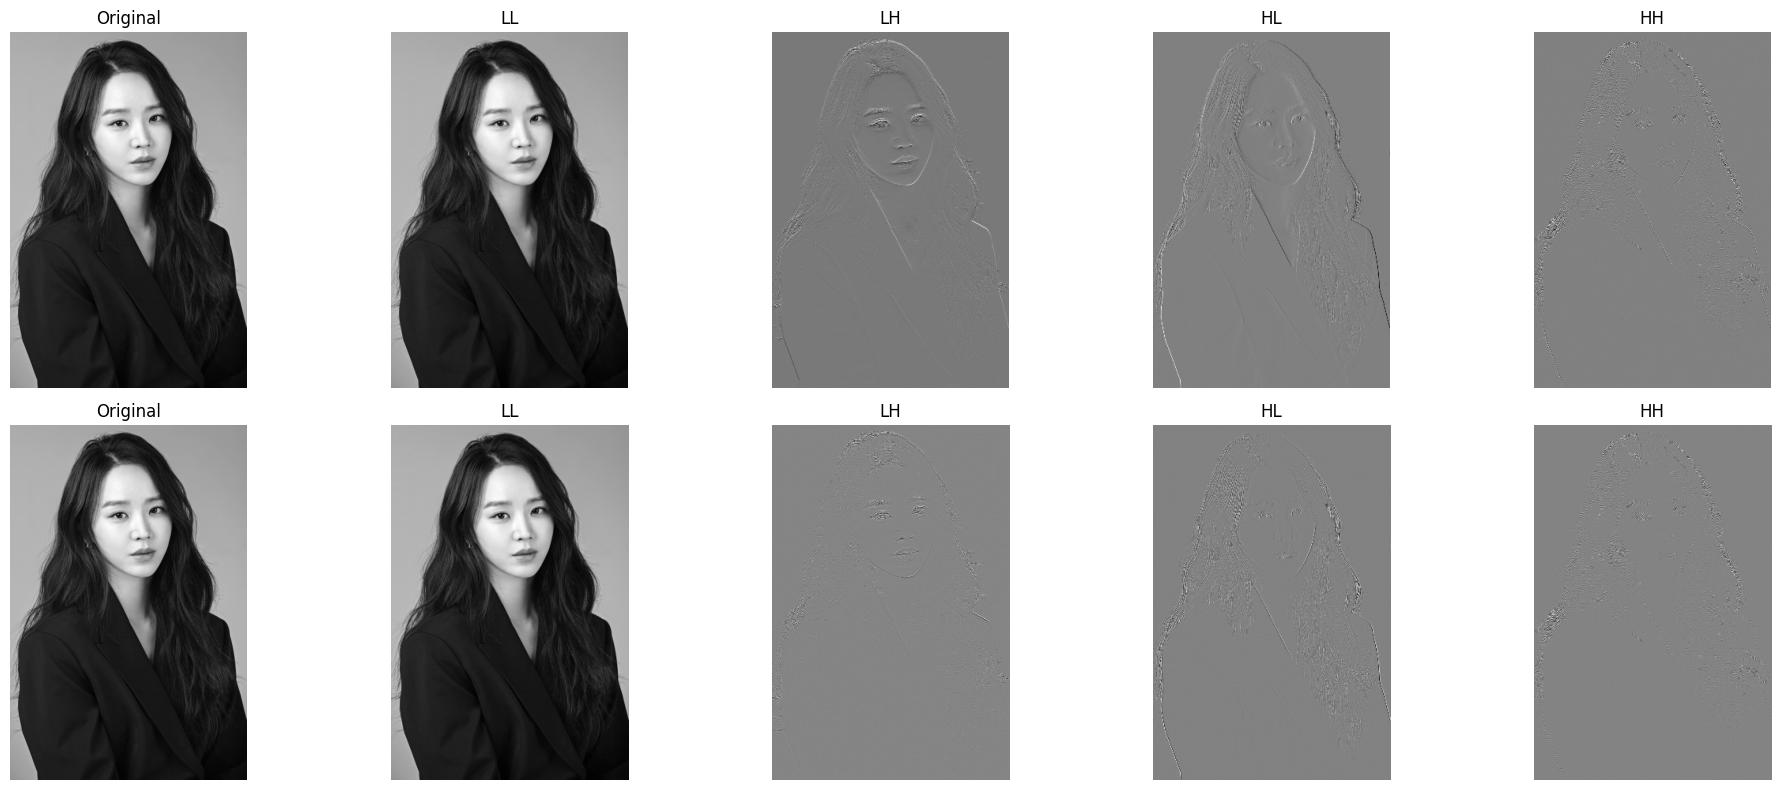

In [22]:
import cv2 
import pywt
import matplotlib.pyplot as plt 

img = cv2.imread("/home/tuong/Courses/CV/opencv-learning/sun.png", 0)

#áp dụng dwt (haar)
coeffs = pywt.dwt2(img, 'haar')
LL, (LH, HL, HH) = coeffs

#áp dụng dwt (db2)
coeffs_db2 = pywt.dwt2(img, 'db2')
LLdb2, (LHdb2, HLdb2, HHdb2) = coeffs_db2

display_images(img, LL, LH, HL, HH, 
            img, LLdb2, LHdb2, HLdb2, HHdb2, 
            titles=['Original', 'LL', 'LH', 'HL', 'HH',
                    'Original', 'LL', 'LH', 'HL', 'HH'])

## Bài 2

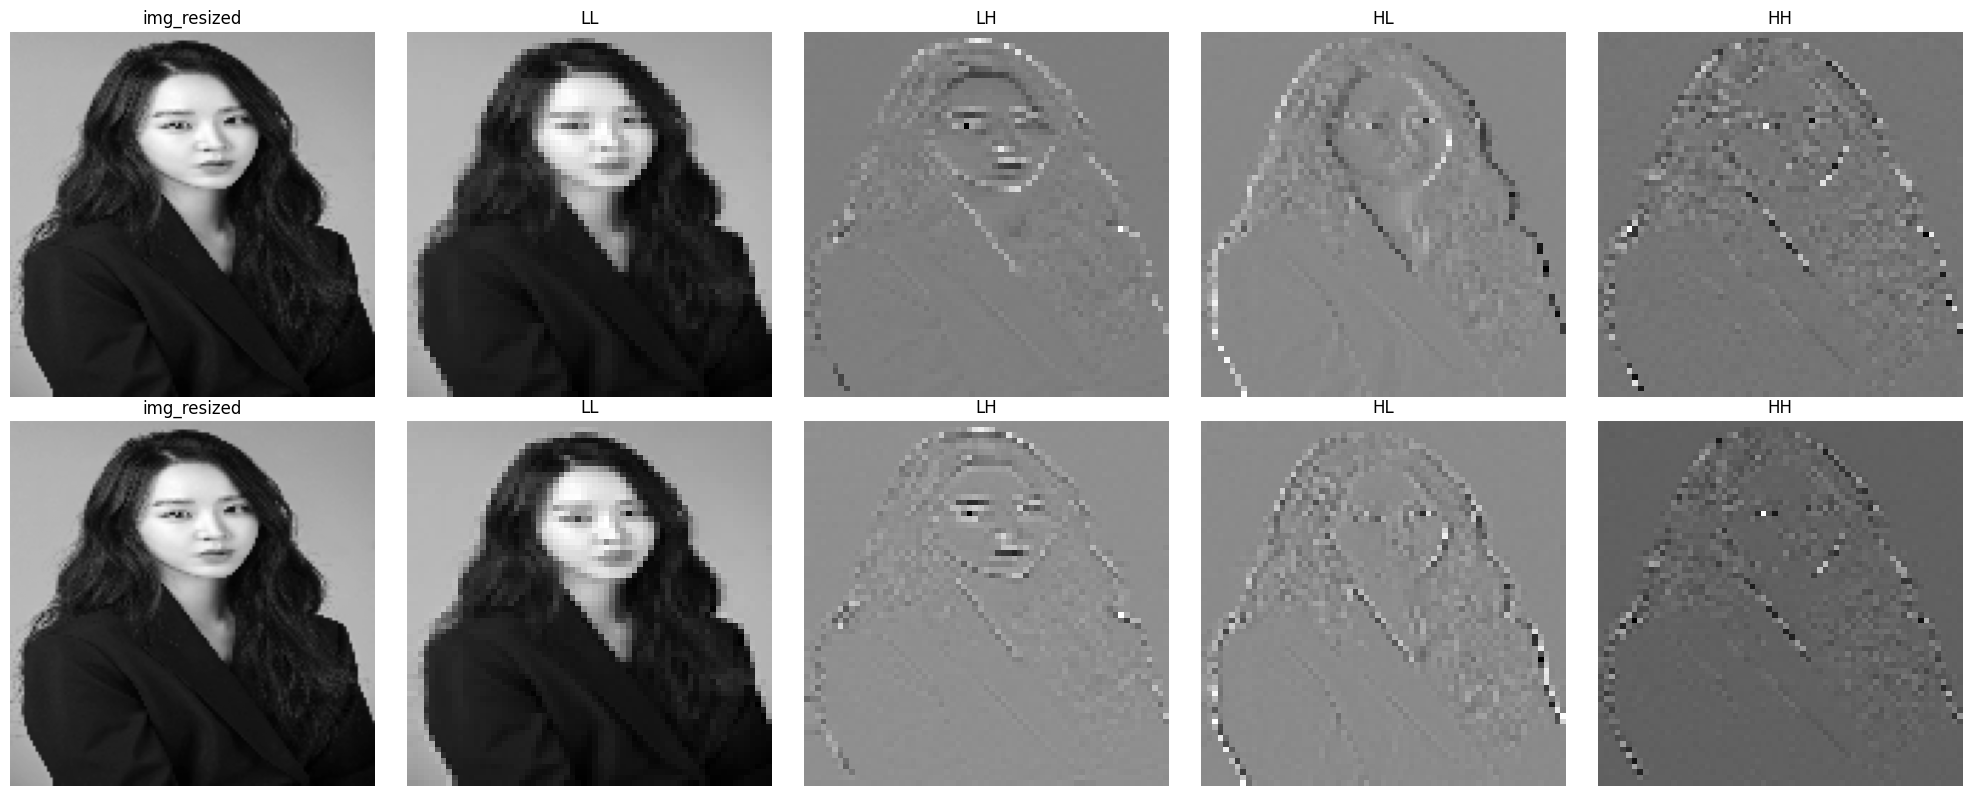

In [24]:
#resize về 128x128
size = (128, 128)
img__resized = cv2.resize(img, size)
#áp dụng dwt (haar)
coeffs = pywt.dwt2(img__resized, 'haar')
LL, (LH, HL, HH) = coeffs

#áp dụng dwt (db2)
coeffs_db2 = pywt.dwt2(img__resized, 'db2')
LLdb2, (LHdb2, HLdb2, HHdb2) = coeffs_db2

display_images(img__resized, LL, LH, HL, HH, 
            img__resized, LLdb2, LHdb2, HLdb2, HHdb2, 
            titles=['img_resized', 'LL', 'LH', 'HL', 'HH',
                    'img_resized', 'LL', 'LH', 'HL', 'HH'])

# Trích xuất đặc trưng

### mục tiêu sau khi có các giá trị LL, LH, ... thì chuyển thành vector đặc trưng

In [35]:
# dùng flatten
import numpy as np 

feature_ft = np.concatenate([
    LL.flatten(),
    LH.flatten(),
    HL.flatten(),
    HH.flatten()
])

In [36]:
# dùng Mean + Std
feature_ms = [
    np.mean(LL),
    np.std(LL),
    np.mean(LH),
    np.std(LH),
    np.mean(HL),
    np.std(HL),
    np.mean(HH),
    np.std(HH),
]

In [53]:
# dùng energy (phù hợp với wavelet) Energy = sum(pixel^2)
def energy(x):
    return np.sum(x**2)

feature_eg = [
    energy(LL),
    energy(LH),
    energy(HL),
    energy(HH)
]
print(feature_eg)

[np.float64(386476084.50000006), np.float64(1333520.5000000005), np.float64(1443431.5000000005), np.float64(1033721.5000000003)]


## Bài 1

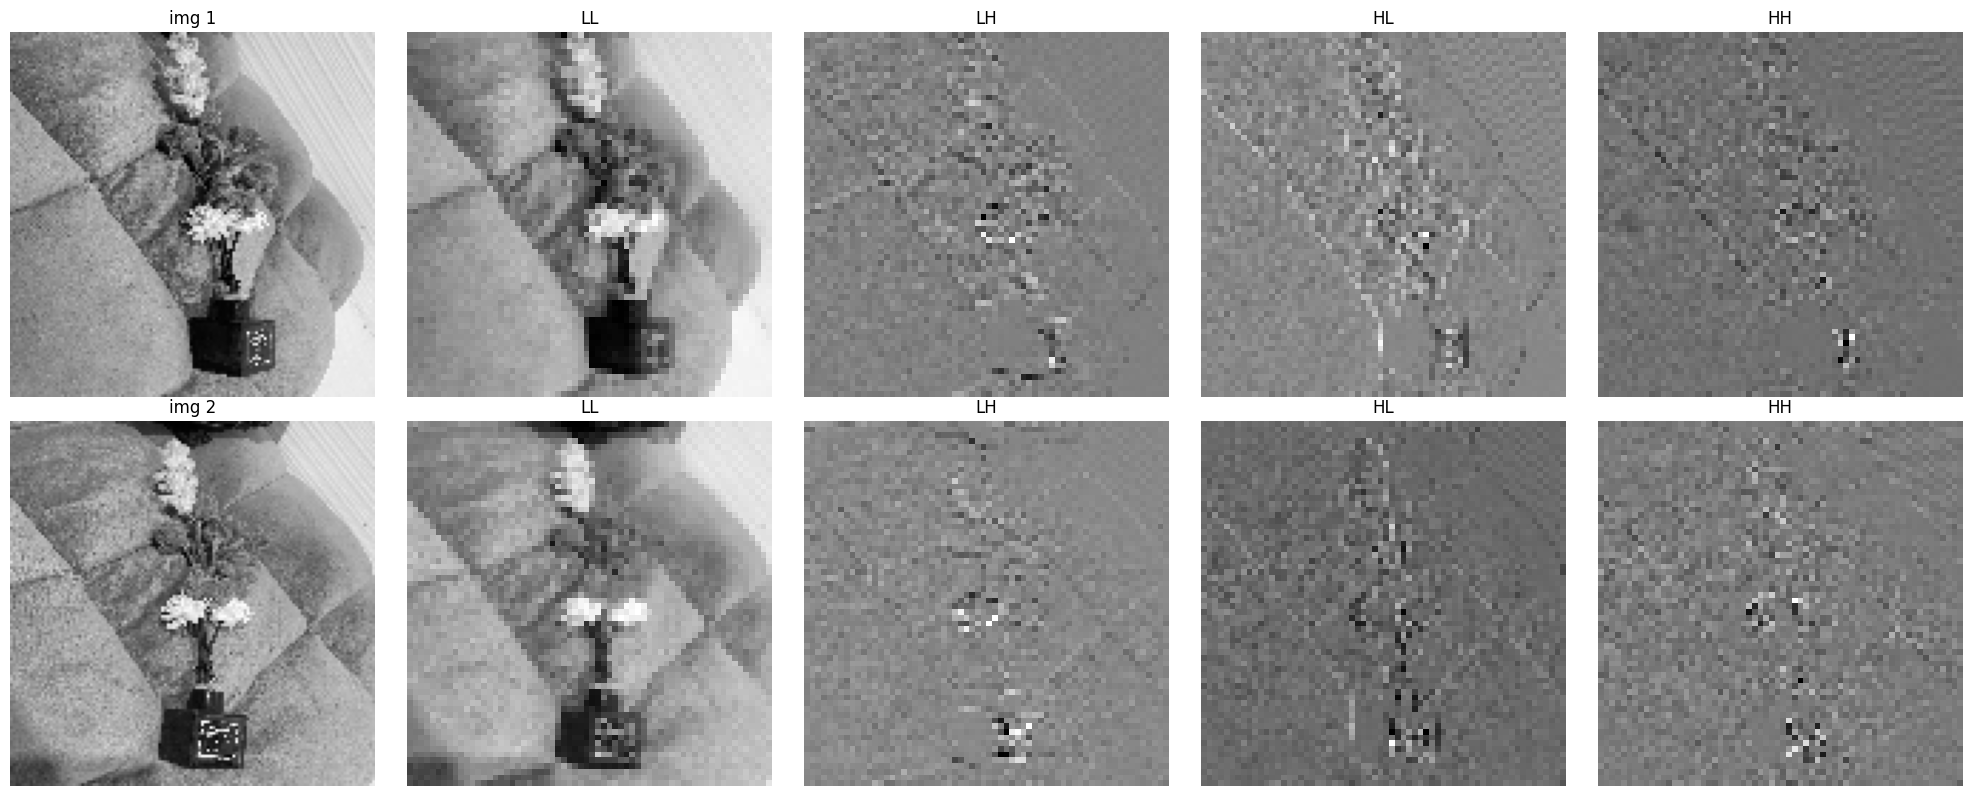

[np.float64(292.8193359375), np.float64(92.79735620428168), np.float64(-0.12060546875000003), np.float64(18.043059126468002), np.float64(-0.7312011718749996), np.float64(18.758081282501582), np.float64(-0.308349609375), np.float64(15.883272131533095)]
[np.float64(281.5982666015625), np.float64(81.35280785037394), np.float64(0.011840820312500111), np.float64(21.601384073179332), np.float64(-0.8431396484375004), np.float64(20.3997732544755), np.float64(0.40588378906250017), np.float64(16.86883906776953)]


In [46]:
img1 = cv2.imread("/home/tuong/Courses/CV/Chap3/data/flower1.jpg", 0)
img2 = cv2.imread("/home/tuong/Courses/CV/Chap3/data/flower2.jpg", 0)
#resize về 128x128
size = (128, 128)
img__resized1 = cv2.resize(img1, size)
img__resized2 = cv2.resize(img2, size)
#áp dụng dwt (haar)
coeffs1 = pywt.dwt2(img__resized1, 'haar')
LL, (LH, HL, HH) = coeffs1
coeffs2 = pywt.dwt2(img__resized2, 'haar')
LL2, (LH2, HL2, HH2) = coeffs2

display_images(img__resized1, LL, LH, HL, HH, 
            img__resized2, LL2, LH2, HL2, HH2, 
            titles=['img 1', 'LL', 'LH', 'HL', 'HH',
                    'img 2', 'LL', 'LH', 'HL', 'HH'])


feature = [
        np.mean(LL), np.std(LL),
        np.mean(LH), np.std(LH),
        np.mean(HL), np.std(HL),
        np.mean(HH), np.std(HH)
    ]

feature2 = [
        np.mean(LL2), np.std(LL2),
        np.mean(LH2), np.std(LH2),
        np.mean(HL2), np.std(HL2),
        np.mean(HH2), np.std(HH2)
    ]

print(feature)
print(feature2)

## Bài 2

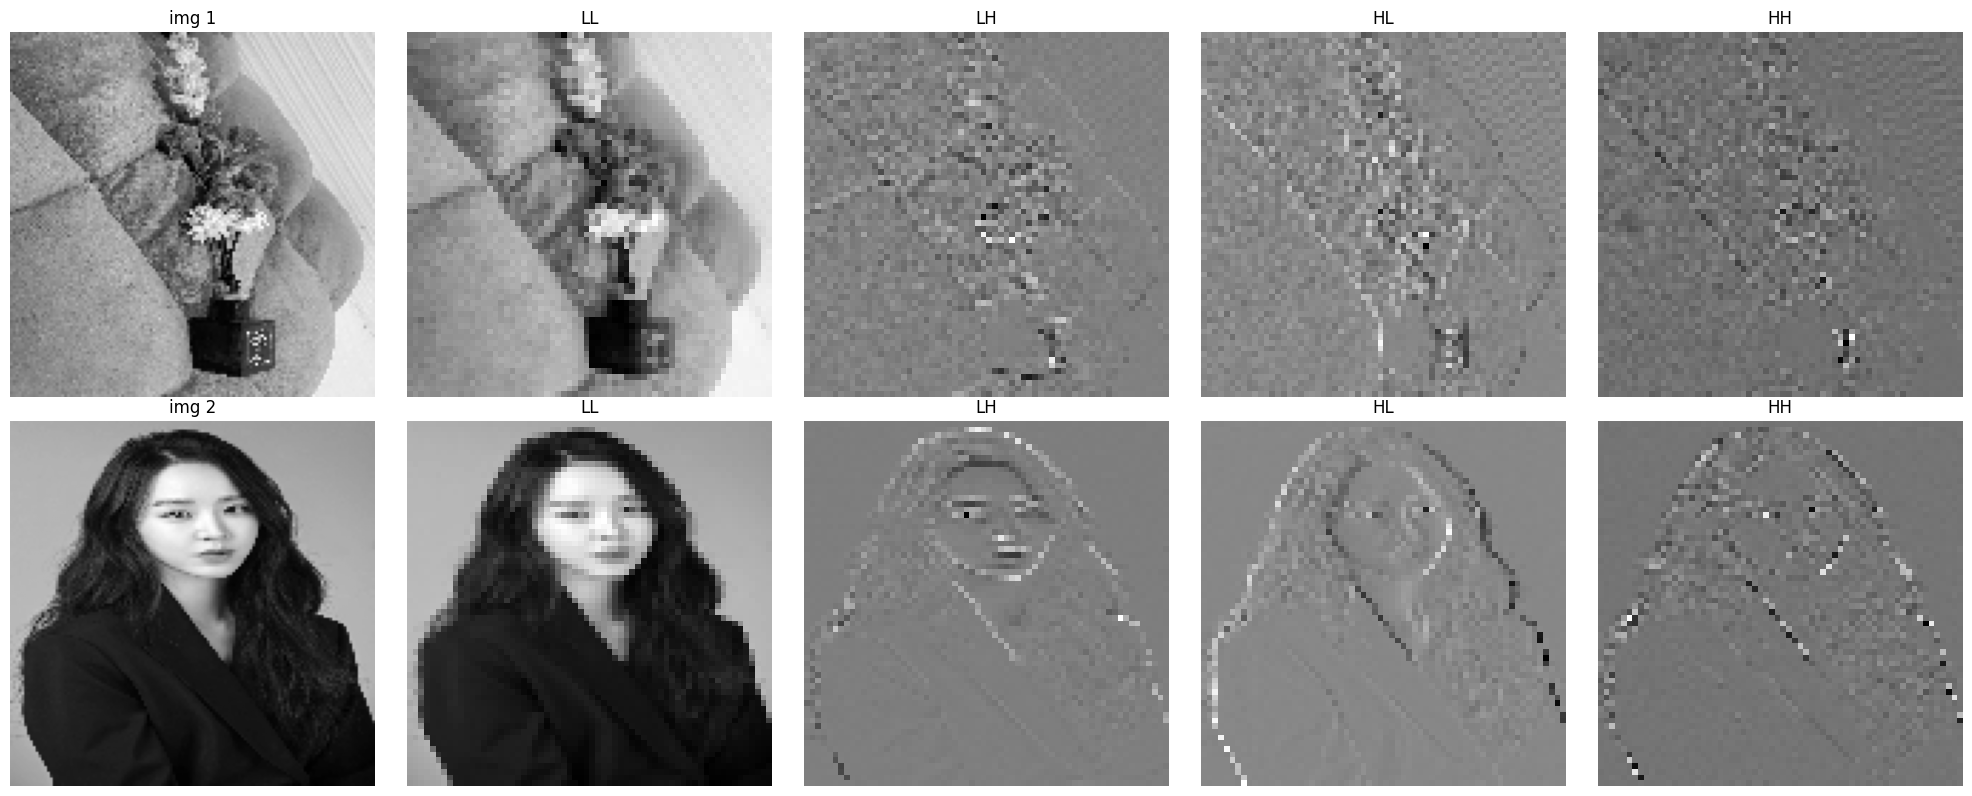

[np.float64(292.8193359375), np.float64(92.79735620428168), np.float64(-0.12060546875000003), np.float64(18.043059126468002), np.float64(-0.7312011718749996), np.float64(18.758081282501582), np.float64(-0.308349609375), np.float64(15.883272131533095)]
[np.float64(185.7520751953125), np.float64(117.36362492134411), np.float64(0.7889404296875), np.float64(11.290565849310799), np.float64(0.31115722656250006), np.float64(13.231194091930128), np.float64(0.19274902343750003), np.float64(7.185573360086351)]


In [48]:
img1 = cv2.imread("/home/tuong/Courses/CV/Chap3/data/flower1.jpg", 0)
img2 = cv2.imread("/home/tuong/Courses/CV/opencv-learning/sun.png", 0)
#resize về 128x128
size = (128, 128)
img__resized1 = cv2.resize(img1, size)
img__resized2 = cv2.resize(img2, size)
#áp dụng dwt (haar)
coeffs1 = pywt.dwt2(img__resized1, 'haar')
LL, (LH, HL, HH) = coeffs1
coeffs2 = pywt.dwt2(img__resized2, 'haar')
LL2, (LH2, HL2, HH2) = coeffs2

display_images(img__resized1, LL, LH, HL, HH, 
            img__resized2, LL2, LH2, HL2, HH2, 
            titles=['img 1', 'LL', 'LH', 'HL', 'HH',
                    'img 2', 'LL', 'LH', 'HL', 'HH'])


feature = [
        np.mean(LL), np.std(LL),
        np.mean(LH), np.std(LH),
        np.mean(HL), np.std(HL),
        np.mean(HH), np.std(HH)
    ]

feature2 = [
        np.mean(LL2), np.std(LL2),
        np.mean(LH2), np.std(LH2),
        np.mean(HL2), np.std(HL2),
        np.mean(HH2), np.std(HH2)
    ]

print(feature)
print(feature2)

## Bài 3

In [50]:
""" 
So sánh 3 cách:
Chỉ dùng LL
LL + LH + HL
LL + LH + HL + HH (full)

hàm extract feature cho từng cách
"""
def feature_LL(img):
    LL, (LH, HL, HH) = pywt.dwt2(img, 'haar')
    return np.array([
        np.mean(LL),
        np.std(LL)
    ])

def feature_LL_LH_HL(img):
    LL, (LH, HL, HH) = pywt.dwt2(img, 'haar')
    return np.array([
        np.mean(LL), np.std(LL),
        np.mean(LH), np.std(LH),
        np.mean(HL), np.std(HL),
    ])

def feature_full(img):
    LL, (LH, HL, HH) = pywt.dwt2(img, 'haar')
    return np.array([
        np.mean(LL), np.std(LL),
        np.mean(LH), np.std(LH),
        np.mean(HL), np.std(HL),
        np.mean(HH), np.std(HH),
    ])

def distance(a, b):
    return np.linalg.norm(a - b)  # Euclidean


def load_img(path):
    img = cv2.imread(path, 0)
    return cv2.resize(img, (128, 128))

A = load_img('/home/tuong/Courses/CV/Chap3/data/flower1.jpg')
B = load_img('/home/tuong/Courses/CV/Chap3/data/flower2.jpg')
C = load_img('/home/tuong/Courses/CV/opencv-learning/sun.png')

In [51]:
for func in [feature_LL, feature_LL_LH_HL, feature_full]:
    fA = func(A)
    fB = func(B)
    fC = func(C)

    print("====", func.__name__, "====")
    print("A vs B (giống):", distance(fA, fB))
    print("A vs C (khác):", distance(fA, fC))

==== feature_LL ====
A vs B (giống): 16.027790991488796
A vs C (khác): 109.84944188076007
==== feature_LL_LH_HL ====
A vs B (giống): 16.500817715074085
A vs C (khác): 110.20415742503546
==== feature_full ====
A vs B (giống): 16.54564766938269
A vs C (khác): 110.54798676376079
